# **Lennard-Jones gas**

In this code we simulate a set of N particles subjected to Lennard-Jones interactions and confined in a 2D rectangular box. We do this by using the 12-6 Lennard-Jones potential. Then, we solve numerically the Newton's law of motion using Runge-kutta 4. Besides, we use a rustic method of adaptive step by reducing the time step when two particles are *close enough*. The condition for *close enough* is that any of the forces between the particles be greater than or equal to `F0`, which is the Lennard-Jones force between two particles at some distant `R0`. This distance must be choose by the user.

**Credits**
* Juan Andrés Guarín Rojas
* [GitHub](https://github.com/AndresGuarin)

# **Import libraries**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import LJGas.solver.particles as partic
import LJGas.solver.animation as ani
import LJGas.analysis.pressure as press

#import LJGas.solver.animation2 as ani
#import LJGas.solver.particles2 as partic

from LJGas.analysis.visualization import moving_mean

from datetime import datetime

# **1. Simulation of 10 particles**

In [10]:
# Choose parameters 
h = 0.05; N = 3500; R0 = 1.05; h0 = 0.01; box=[200,100]; R1=3

# Set intial conditions
Np = 8

np.random.seed(174489)
X0 = np.random.random(Np)*box[0]*0.9 - box[0]*0.9/2
Y0 = np.random.random(Np)*box[1]*0.9 - box[1]*0.9/2
Theta0 = np.random.random(Np)*2*np.pi - np.pi
Vx0 = 2*np.cos(Theta0) + np.random.random(Np)*0.1 - 0.05
Vy0 = 2*np.sin(Theta0) + np.random.random(Np)*0.1 - 0.05

sim = partic.LJGas(h,N,Np,R0,h0,box,R1,verbose=False)
s = sim.simulate([X0,Y0,Vx0,Vy0]); self1 = sim.get_self()
Lh = self1.Lh; time = np.zeros(N+1)
for i in range(N): time[i+1] = time[i]+Lh[i]

In [11]:
sI = []; 
sim1 = partic.LJGas(h,N,1,R0,h0,box,R1,verbose=False)
for i in range(Np):
    sI.append(sim1.simulate([X0[[i]],Y0[[i]],Vx0[[i]],Vy0[[i]]]))

In [12]:
s1=s
for i in range(4):
    for j in range(Np):
        s1[i] = np.concatenate([s1[i],sI[j][i]],1)

In [13]:
self1.Np = 2*Np

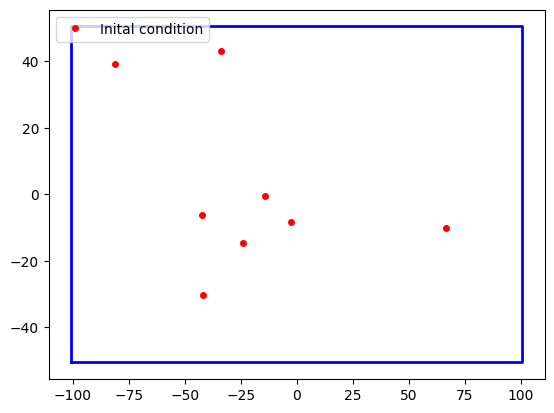

In [14]:
%matplotlib inline

Xf = s[0][-1,:]; Yf = s[1][-1,:]; Vxf = s[2][-1,:]; Vyf = s[3][-1,:]

b0 = box[0]/2 + R0/2; b1 = box[1]/2 + R0/2
plt.plot([-b0,b0,b0,-b0,-b0],[-b1,-b1,b1,b1,-b1],'-b',lw=2)
plt.plot(X0,Y0,'or',ms=4,label='Inital condition')
#plt.plot(X0,Y0,'or',ms=4,label='Final condition')
plt.legend(loc='upper left')
plt.show()

# **2. Animation**

In [15]:
date = 'module_test'
#date = datetime.now().strftime("%m-%d_%H-%M-%S")

In [20]:
%matplotlib auto
%matplotlib auto

ani.animate_path(self1,s,dj=20,kind=2,save=False,name=date+'test.mp4',verbose=True,plot_params=['-b','or',1,5,0.3],amp=3,interval=100)
#plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg
